In [1]:
#Feature Construction: (Use packages that are applicable)
#1. Dummy coding categorical(nominal) variables.
#2. Encoding categorical(ordinal) variables.
#3. Transforming numeric(continuous)features to categorical features

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df=pd.read_csv(r"C:\Users\immad\Downloads\homeprices.csv")
df

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000
5,west windsor,2600,585000
6,west windsor,2800,615000
7,west windsor,3300,650000
8,west windsor,3600,710000
9,robinsville,2600,575000


In [7]:
#1. Dummy coding categorical(nominal) variables.

In [19]:
#Using pandas to create dummy variables
dummies = pd.get_dummies (df.town)
dummies

,monroe township,robinsville,west windsor
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
5,False,False,True
6,False,False,True
7,False,False,True
8,False,False,True
9,False,True,False


In [20]:
#to avoid dummpy variable trap, remove one column
dummies = dummies.drop(['west windsor'], axis='columns')
dummies

,monroe township,robinsville
0,True,False
1,True,False
2,True,False
3,True,False
4,True,False
5,False,False
6,False,False
7,False,False
8,False,False
9,False,True


In [21]:
#add these dummies to original df. add olumns of ho.
merged = pd.concat ([df, dummies], axis='columns')
merged

,town,area,price,monroe township,robinsville
0,monroe township,2600,550000,True,False
1,monroe township,3000,565000,True,False
2,monroe township,3200,610000,True,False
3,monroe township,3600,680000,True,False
4,monroe township,4000,725000,True,False
5,west windsor,2600,585000,False,False
6,west windsor,2800,615000,False,False
7,west windsor,3300,650000,False,False
8,west windsor,3600,710000,False,False
9,robinsville,2600,575000,False,True


In [22]:
#we do dummy var not require 'town variable as Tt Is replaced h
#Hence drop town.
final= merged.drop(['town'], axis='columns')
final

,area,price,monroe township,robinsville
0,2600,550000,True,False
1,3000,565000,True,False
2,3200,610000,True,False
3,3600,680000,True,False
4,4000,725000,True,False
5,2600,585000,False,False
6,2800,615000,False,False
7,3300,650000,False,False
8,3600,710000,False,False
9,2600,575000,False,True


In [12]:
#Another method of encoding categorical(nominal) variables using "one hot encoding"

In [23]:
df1=pd.read_csv(r"C:\Users\immad\Downloads\homeprices.csv")
df1

,town,area,price
0,monroe township,2600,550000
1,monroe township,3000,565000
2,monroe township,3200,610000
3,monroe township,3600,680000
4,monroe township,4000,725000
5,west windsor,2600,585000
6,west windsor,2800,615000
7,west windsor,3300,650000
8,west windsor,3600,710000
9,robinsville,2600,575000


In [25]:
from sklearn.preprocessing import OneHotEncoder
ohe= OneHotEncoder (handle_unknown="ignore")
X1=ohe.fit_transform(df1[['town']])
X1=pd.DataFrame (X1.toarray())
#Droping one column
X1 = X1.iloc[:, 1:]
X1

,1,2
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
5,0.0,1.0
6,0.0,1.0
7,0.0,1.0
8,0.0,1.0
9,1.0,0.0


In [15]:
#Encoding categorical(ordinal) variables(Using Label encoder)

In [16]:
import pandas as pd
iris= pd.read_csv(r"C:\Users\immad\Downloads\Iris1.csv")
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [17]:
#Label encoding of nominal data using sklearn
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
iris_1=iris
iris_1.Species=le.fit_transform(iris_1.Species)
iris_1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [18]:
#Observation
#1.Species attribute is the nominal attribute
#2.SO it needs to be converted into numeric
#Type Markdown and LaTeX: 𝛼2

In [19]:
#3. Transforming numeric(continuous)features to categorical features

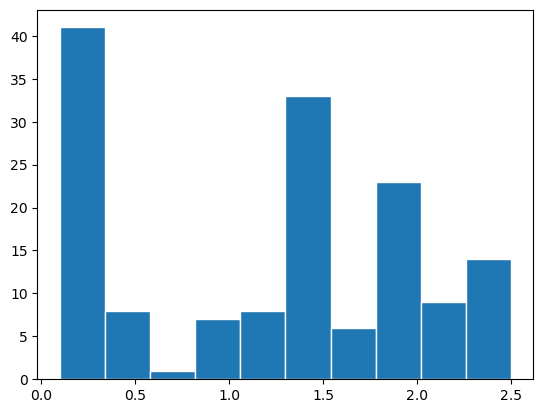

In [20]:
import matplotlib.pyplot as plt
plt.hist(iris.PetalWidthCm,edgecolor="w")
plt.show()

In [26]:
iris['petal_category']=pd.cut(iris.PetalWidthCm ,bins=[0,1,2,2.5])
print(iris['petal_category'])

0      (0.0, 1.0]
1      (0.0, 1.0]
2      (0.0, 1.0]
3      (0.0, 1.0]
4      (0.0, 1.0]
          ...    
145    (2.0, 2.5]
146    (1.0, 2.0]
147    (1.0, 2.0]
148    (2.0, 2.5]
149    (1.0, 2.0]
Name: petal_category, Length: 150, dtype: category
Categories (3, interval[float64, right]): [(0.0, 1.0] < (1.0, 2.0] < (2.0, 2.5]]


In [28]:
print(iris['petal_category'].value_counts())

(1.0, 2.0]    70
(0.0, 1.0]    57
(2.0, 2.5]    23
Name: petal_category, dtype: int64


In [29]:
#2. Encoding categorical(ordinal) variables

In [30]:
from sklearn.preprocessing import OrdinalEncoder
encoder=OrdinalEncoder()
iris['petal_category']=encoder.fit_transform(iris[['petal_category']])
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,petal_category
0,1,5.1,3.5,1.4,0.2,0,0.0
1,2,4.9,3.0,1.4,0.2,0,0.0
2,3,4.7,3.2,1.3,0.2,0,0.0
3,4,4.6,3.1,1.5,0.2,0,0.0
4,5,5.0,3.6,1.4,0.2,0,0.0
...,...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2,2.0
146,147,6.3,2.5,5.0,1.9,2,1.0
147,148,6.5,3.0,5.2,2.0,2,1.0
148,149,6.2,3.4,5.4,2.3,2,2.0


In [31]:
#Observation
#The attribute PetalLengthCm is converted into Ordinal type and then it is encoded into
#continuous data
#Scikitlearn Ordinal Encoder is used to transform categorical data into continuous data